# LoRA CNN Experiment


## Imports

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## MNIST

In [33]:
transform = transforms.Compose([ transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True,  transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")

Train samples : 60,000
Test  samples : 10,000


## Baseline Lousy CNN

Designing a small but horrible CNN
- Has 2 conv layers
- No Batchnorm, no dropout
- A single FCN layer

In [34]:
class LousyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(8 * 7 * 7, 32)
        self.fc2   = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def count_params(model, trainable_only=False):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


baseline_model = LousyCNN().to(DEVICE)
total_params   = count_params(baseline_model)
print(f"Total parameters : {total_params:,}")
print(baseline_model)

Total parameters : 13,242
LousyCNN(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=392, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


## Utils Code

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    loss_sum = 0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()

    loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            out = model(X)
            loss = criterion(out, y)

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


def train(model, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"{epoch+1}/{epochs} -> "
              f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    return model, history

## Training without LoRA

In [36]:
CNN_EPOCHS = 5

print(f"Training Baseline CNN  ({total_params:,} parameters)")

cnn_model, cnn_history = train(baseline_model, epochs=CNN_EPOCHS)

print("Training complete")




Training Baseline CNN  (13,242 parameters)
1/5 -> train_loss: 0.3501, train_acc: 0.8954 | val_loss: 0.1363, val_acc: 0.9593
2/5 -> train_loss: 0.1178, train_acc: 0.9639 | val_loss: 0.0810, val_acc: 0.9734
3/5 -> train_loss: 0.0832, train_acc: 0.9745 | val_loss: 0.0731, val_acc: 0.9762
4/5 -> train_loss: 0.0681, train_acc: 0.9792 | val_loss: 0.0595, val_acc: 0.9804
5/5 -> train_loss: 0.0584, train_acc: 0.9818 | val_loss: 0.0548, val_acc: 0.9828
Training complete


## LoRA

- `Lora Linear`: wraps existing linear layer with LoRA adapters. Out = Wo * X + (B A) * X * (alpha/r)
- `inject_lora`:  Clone the model, freeze all params, then replace each Linear with a LoRALinear. Conv layers stay frozen.

In [37]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, rank: int = 4, alpha: float = 1.0):
        super().__init__()
        in_f, out_f = linear.in_features, linear.out_features
        self.rank   = rank
        self.scale  = alpha / rank

        # Frozen original weights
        self.weight = linear.weight
        self.bias   = linear.bias
        self.weight.requires_grad = False
        if self.bias is not None:
            self.bias.requires_grad = False

        # Trainable low-rank matrices
        self.A = nn.Parameter(torch.randn(rank, in_f) * 0.01)   # [r, in]
        self.B = nn.Parameter(torch.zeros(out_f, rank))          # [out, r]

    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.A), self.B) * self.scale
        return base + lora


def inject_lora(model, rank=4, alpha=1.0):

    lora_model = copy.deepcopy(model)

    # Freeze
    for p in lora_model.parameters():
        p.requires_grad = False

    # Replace Linear layers
    for name, module in list(lora_model.named_children()):
        if isinstance(module, nn.Linear):
            setattr(lora_model, name, LoRALinear(module, rank=rank, alpha=alpha))

    return lora_model


LORA_RANK  = 4
LORA_ALPHA = 1.0

lora_model = inject_lora(baseline_model, rank=LORA_RANK, alpha=LORA_ALPHA)
lora_model = lora_model.to(DEVICE)

total_lora     = count_params(lora_model, trainable_only=False)
trainable_lora = count_params(lora_model, trainable_only=True)

print(f"Total parameters   (LoRA model) : {total_lora:,}")
print(f"Trainable parameters (LoRA only): {trainable_lora:,}")
print(f"Frozen parameters               : {total_lora - trainable_lora:,}")
print(f"Trainable %                     : {100*trainable_lora/total_lora:.2f}%")

Total parameters   (LoRA model) : 15,106
Trainable parameters (LoRA only): 1,864
Frozen parameters               : 13,242
Trainable %                     : 12.34%


In [38]:
LORA_EPOCHS = 5

print(f"Training with LoRA  (rank={LORA_RANK}, alpha={LORA_ALPHA})")
print(f"Only {trainable_lora} of {total_lora} params are updated")

lora_model, lora_history = train(lora_model, epochs=LORA_EPOCHS, lr=1e-3)


Training with LoRA  (rank=4, alpha=1.0)
Only 1864 of 15106 params are updated
1/5 -> train_loss: 0.0439, train_acc: 0.9866 | val_loss: 0.0433, val_acc: 0.9858
2/5 -> train_loss: 0.0421, train_acc: 0.9871 | val_loss: 0.0429, val_acc: 0.9854
3/5 -> train_loss: 0.0415, train_acc: 0.9872 | val_loss: 0.0421, val_acc: 0.9864
4/5 -> train_loss: 0.0410, train_acc: 0.9875 | val_loss: 0.0412, val_acc: 0.9867
5/5 -> train_loss: 0.0405, train_acc: 0.9879 | val_loss: 0.0416, val_acc: 0.9866


## Summary Table

In [39]:
print("Metric | Baseline CNN | LoRA")

print("Total parameters |", total_params, "|", total_lora)
print("Trainable parameters |", total_params, "|", trainable_lora)
print("Trainable % |", 100.0, "|", 100 * trainable_lora / total_lora)
print("Training time (s) |", cnn_time, "|", lora_time)

cnn_val_loss, cnn_val_acc = evaluate(cnn_model, test_loader, nn.CrossEntropyLoss())
lora_val_loss, lora_val_acc = evaluate(lora_model, test_loader, nn.CrossEntropyLoss())

print("Final val accuracy |", cnn_val_acc, "|", lora_val_acc)
print("Final val loss |", cnn_val_loss, "|", lora_val_loss)

Metric | Baseline CNN | LoRA
Total parameters | 13242 | 15106
Trainable parameters | 13242 | 1864
Trainable % | 100.0 | 12.339467761154507
Training time (s) | 134.52358173899995 | 130.76159227000005
Final val accuracy | 0.9828 | 0.9866
Final val loss | 0.054770685674156994 | 0.04164173036693613


## Graphs

CHATGPTED THIS

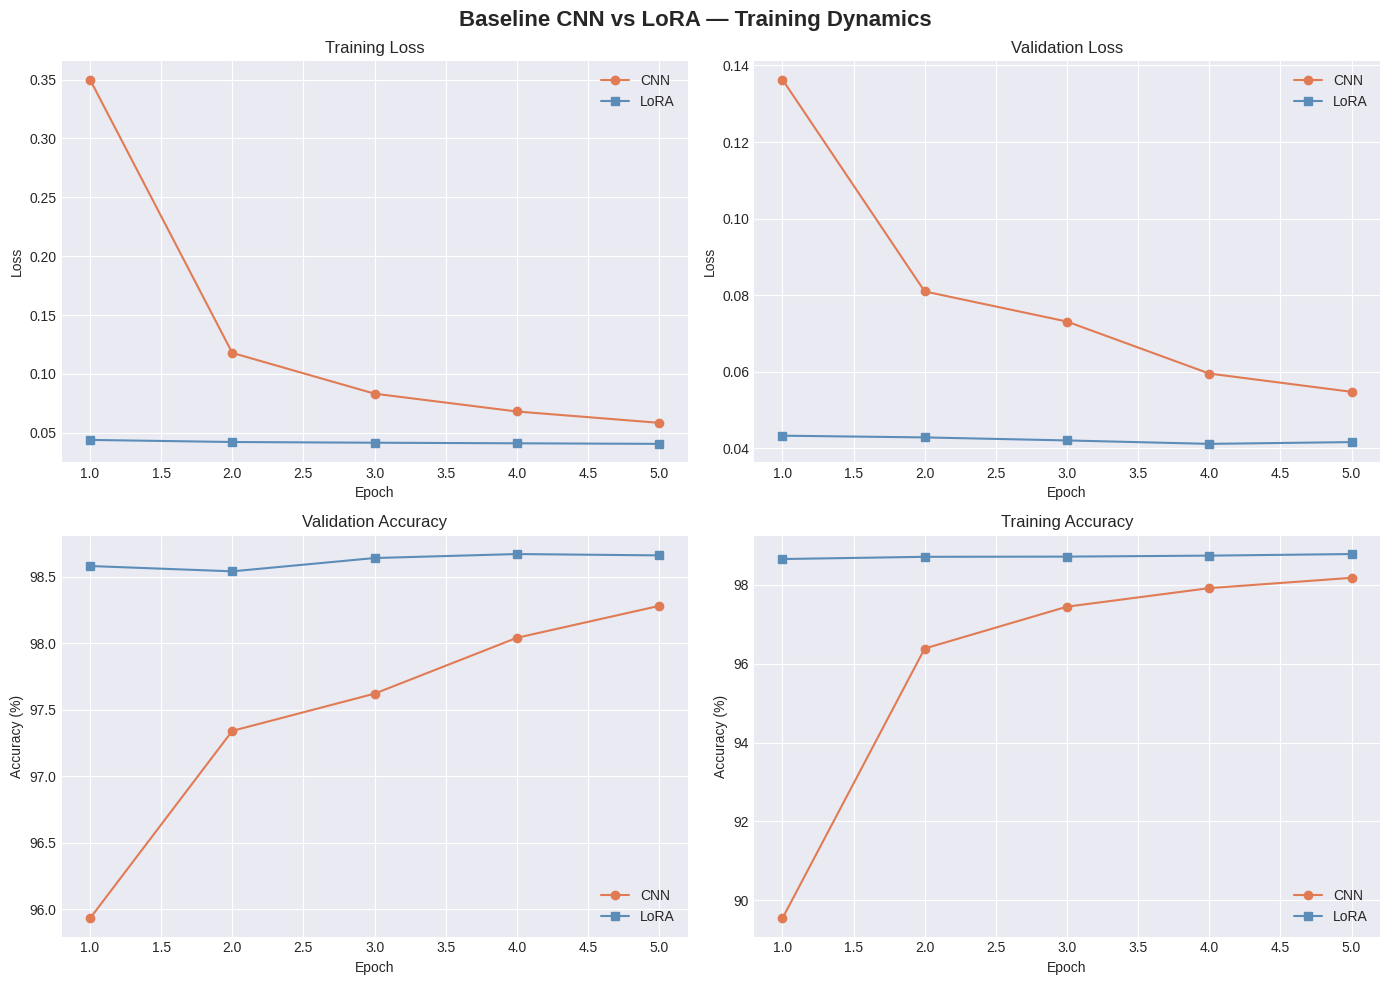

Saved → training_curves.png


In [40]:
epochs_x = list(range(1, CNN_EPOCHS + 1))

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = {"cnn": "#E07B54", "lora": "#5B8DB8"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Baseline CNN vs LoRA — Training Dynamics", fontsize=16, fontweight="bold")

# ── 1. Training Loss ─────────────────────
ax = axes[0, 0]
ax.plot(epochs_x, cnn_history["train_loss"], label="CNN", color=COLORS["cnn"], marker="o")
ax.plot(epochs_x, lora_history["train_loss"], label="LoRA", color=COLORS["lora"], marker="s")
ax.set_title("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# ── 2. Validation Loss ───────────────────
ax = axes[0, 1]
ax.plot(epochs_x, cnn_history["val_loss"], label="CNN", color=COLORS["cnn"], marker="o")
ax.plot(epochs_x, lora_history["val_loss"], label="LoRA", color=COLORS["lora"], marker="s")
ax.set_title("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# ── 3. Val Accuracy ───────────────────────
ax = axes[1, 0]
ax.plot(epochs_x, [x * 100 for x in cnn_history["val_acc"]], label="CNN", color=COLORS["cnn"], marker="o")
ax.plot(epochs_x, [x * 100 for x in lora_history["val_acc"]], label="LoRA", color=COLORS["lora"], marker="s")
ax.set_title("Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()

# ── 4. Train Accuracy ─────────────────────
ax = axes[1, 1]
ax.plot(epochs_x, [x * 100 for x in cnn_history["train_acc"]], label="CNN", color=COLORS["cnn"], marker="o")
ax.plot(epochs_x, [x * 100 for x in lora_history["train_acc"]], label="LoRA", color=COLORS["lora"], marker="s")
ax.set_title("Training Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → training_curves.png")

## References

This work was possible due to:

1. [Umar Jamil - LoRA](https://www.youtube.com/watch?v=PXWYUTMt-AU&t=1433s)
2. [CodeEmporium - LoRA](https://www.youtube.com/watch?v=Bq9zqTJDsjg&t=1630s)